# Phase 05D_B1 - CNN Frozen-Feature Supervised Baselines

This notebook compares the proposed clean QAdp system against frozen CNN visual backbones with supervised 23-class MLP heads.

This notebook follows the Phase 05D_A4 persistence/checkpointing structure:
frozen visual features are cached per unique image and MLP training resumes by
model variant and seed. Existing A4/QAdp notebooks and results are preserved.


## 1. Install Runtime Dependencies


In [1]:
import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("matplotlib", "matplotlib"),
    ("numpy", "numpy"),
    ("pandas", "pandas==2.2.2"),
    ("PIL", "pillow==10.4.0"),
    ("sklearn", "scikit-learn==1.6.1"),
    ("torch", "torch"),
    ("torchvision", "torchvision"),
    ("tqdm", "tqdm"),
]:
    ensure_package(import_name, pip_name)

print("Frozen visual-backbone supervised baseline dependencies are available.")


Frozen visual-backbone supervised baseline dependencies are available.


## 2. Mount Drive and Configure Paths


In [3]:
from pathlib import Path
import json
import math
import os
import random
import shutil
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from sklearn.metrics import accuracy_score, f1_score, log_loss
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False


def ensure_drive_connection(project_dir: Path, mount_point: str = "/content/drive") -> None:
    if not IN_COLAB:
        return

    def probe_path(target: Path):
        probe_target = target if target.exists() else target.parent
        return os.listdir(str(probe_target))

    try:
        probe_path(project_dir)
    except OSError as exc:
        if getattr(exc, "errno", None) != 107:
            raise
        print("Detected stale Google Drive mount. Remounting...")
        try:
            drive.flush_and_unmount()
            time.sleep(2)
        except Exception:
            pass
        drive.mount(mount_point, force_remount=True)
        time.sleep(2)
        probe_path(project_dir)


PROJECT_DRIVE_DIR = Path("/content/drive/MyDrive/AUGR-VQA")
if not PROJECT_DRIVE_DIR.exists():
    PROJECT_DRIVE_DIR = Path.cwd()
ensure_drive_connection(PROJECT_DRIVE_DIR)

DATASET_CSV_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_3/p3a_brats_vqa_dataset" / "dataset_btumqa_225k",
    PROJECT_DRIVE_DIR / "Dataset" / "dataset_btumqa_225k",
    PROJECT_DRIVE_DIR / "dataset_btumqa_225k",
    Path.cwd() / "Dataset" / "dataset_btumqa_225k",
]
PHASE3B_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_3/p3b_text_preprocessing" / "dataset_btumqa_225k",
    PROJECT_DRIVE_DIR / "phase_3/p3b_text_preprocessing",
    Path.cwd() / "phase_3/p3b_text_preprocessing" / "dataset_btumqa_225k",
]
IMAGE_BASE_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats" / "dataset_cache" / "rsnabrats20212d-001",
    PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats" / "dataset_cache" / "rsna-brats-2021-2d",
    PROJECT_DRIVE_DIR / "Dataset" / "rsna-brats-2021-2d",
    PROJECT_DRIVE_DIR / "rsna-brats-2021-2d",
    PROJECT_DRIVE_DIR / "phase_0_data" / "rsna-brats-2021-2d",
]
DRIVE_DATASET_ZIP_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_1/p1a_segmentation_monai_brats" / "dataset_cache" / "rsnabrats20212d.zip",
    PROJECT_DRIVE_DIR / "phase_2/p2b_mc_dropout_uncertainty" / "dataset_cache" / "rsnabrats20212d.zip",
    PROJECT_DRIVE_DIR / "phase_2/p2b_mc_dropout_uncertainty" / "dataset_cache" / "rsnabrats20212d.zip",
]

LOCAL_DATASET_DIR = Path("/content/phase05d_b1_rsnabrats20212d")
LOCAL_DATASET_ZIP = LOCAL_DATASET_DIR / "rsnabrats20212d.zip"
LOCAL_MONTAGE_DIR = Path("/content/phase05d_b1_montage_cache")
LOCAL_MASK_CACHE_DIR = Path("/content/phase05d_b1_monai_mask_cache")
LOCAL_MODEL_CACHE_DIR = Path("/content/phase05d_b1_model_cache")
LOCAL_FEATURE_CACHE_DIR = Path("/content/phase05d_b1_feature_cache")
LOCAL_MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(LOCAL_MODEL_CACHE_DIR / "huggingface")
os.environ["TRANSFORMERS_CACHE"] = str(LOCAL_MODEL_CACHE_DIR / "transformers")
os.environ["XDG_CACHE_HOME"] = str(LOCAL_MODEL_CACHE_DIR / "xdg")


def first_existing_dir(candidates, name: str) -> Path:
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {name}. Checked:\n" + "\n".join(str(p) for p in candidates))


def looks_like_image_base(path: Path) -> bool:
    if not path.exists():
        return False
    modality_dirs = [path / modality for modality in ["flair", "t1", "t1ce", "t2"]]
    return all(modality_dir.exists() for modality_dir in modality_dirs) and any(
        (path / "flair").glob("flair_BraTS2021_*.png")
    )


def find_extracted_image_base(root: Path):
    if looks_like_image_base(root):
        return root
    if not root.exists():
        return None
    for candidate in root.rglob("*"):
        if candidate.is_dir() and looks_like_image_base(candidate):
            return candidate
    return None


def prepare_local_image_base() -> Path:
    existing_local = find_extracted_image_base(LOCAL_DATASET_DIR)
    if existing_local is not None:
        print("Using existing local extracted image directory:", existing_local)
        return existing_local

    drive_zip = next((path for path in DRIVE_DATASET_ZIP_CANDIDATES if path.exists()), None)
    if drive_zip is not None:
        LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)
        if not LOCAL_DATASET_ZIP.exists() or LOCAL_DATASET_ZIP.stat().st_size != drive_zip.stat().st_size:
            print("Restoring RSNA-BraTS 2D zip from Drive cache:", drive_zip)
            shutil.copy2(drive_zip, LOCAL_DATASET_ZIP)
        else:
            print("Local RSNA-BraTS 2D zip already exists:", LOCAL_DATASET_ZIP)

        print("Extracting RSNA-BraTS 2D dataset locally. This may take several minutes...")
        with zipfile.ZipFile(LOCAL_DATASET_ZIP, "r") as zip_ref:
            zip_ref.extractall(LOCAL_DATASET_DIR)

        extracted_base = find_extracted_image_base(LOCAL_DATASET_DIR)
        if extracted_base is None:
            raise FileNotFoundError("Dataset zip was extracted, but no flair/t1/t1ce/t2 PNG folder was found.")
        print("Using extracted image directory:", extracted_base)
        return extracted_base

    for candidate in IMAGE_BASE_CANDIDATES:
        if looks_like_image_base(candidate):
            print("Using Drive image directory because no local zip cache was found:", candidate)
            return candidate

    raise FileNotFoundError(
        "Could not find RSNA-BraTS 2D image directory or cached dataset zip. "
        "Checked image dirs:\n"
        + "\n".join(str(path) for path in IMAGE_BASE_CANDIDATES)
        + "\n\nChecked zip caches:\n"
        + "\n".join(str(path) for path in DRIVE_DATASET_ZIP_CANDIDATES)
    )


DATASET_DIR = first_existing_dir(DATASET_CSV_CANDIDATES, "BTUMQA-225K dataset directory")
PHASE3B_DIR = first_existing_dir(PHASE3B_CANDIDATES, "Phase 3B text embedding directory")
IMAGE_BASE_DIR = prepare_local_image_base()

TRAIN_CSV_PATH = DATASET_DIR / "btumqa_225k_train.csv"
VAL_CSV_PATH = DATASET_DIR / "btumqa_225k_val.csv"
TEST_CSV_PATH = DATASET_DIR / "btumqa_225k_test.csv"
EMBEDDINGS_TRAIN_PATH = PHASE3B_DIR / "text_embeddings_train.pt"
EMBEDDINGS_VAL_PATH = PHASE3B_DIR / "text_embeddings_val.pt"
EMBEDDINGS_TEST_PATH = PHASE3B_DIR / "text_embeddings_test.pt"
ANSWER_VOCAB_PATH = PHASE3B_DIR / "answer_vocab.json"

PHASE1_SEGMENTATION_DIR = PROJECT_DRIVE_DIR / "phase_1/p1a_segmentation_monai_brats"
PHASE1_MASK_DIR = PHASE1_SEGMENTATION_DIR / "generated_masks_rsna_2d"
PHASE1_MASK_MANIFEST_PATH = PHASE1_SEGMENTATION_DIR / "logs" / "global_mask_manifest.csv"

PHASE5D_BASE_DIR = PROJECT_DRIVE_DIR / "phase_5/p5d_modern_baseline_comparison_models"
PHASE5D_RUN_DIR = PHASE5D_BASE_DIR / "cnn_model_comparison" / "phase05d_b1_cnn_frozen_feature_supervised_baselines"
FEATURES_DIR = PHASE5D_RUN_DIR / "features"
PREDICTIONS_DIR = PHASE5D_RUN_DIR / "predictions"
TABLES_DIR = PHASE5D_RUN_DIR / "tables"
FIGURES_DIR = PHASE5D_RUN_DIR / "figures"
REPORTS_DIR = PHASE5D_RUN_DIR / "reports"
DONE_DIR = PHASE5D_RUN_DIR / "done"
for path in [FEATURES_DIR, PREDICTIONS_DIR, TABLES_DIR, FIGURES_DIR, REPORTS_DIR, DONE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PHASE5B_RESULT_DIR = (
    PROJECT_DRIVE_DIR
    / "phase_5/p5b_final_evaluation_ablation_calibration"
    / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
)

print("Project dir:", PROJECT_DRIVE_DIR)
print("Dataset dir:", DATASET_DIR)
print("Phase 3B dir:", PHASE3B_DIR)
print("Image base dir:", IMAGE_BASE_DIR)
print("B1 output dir:", PHASE5D_RUN_DIR)
print("Local feature cache:", LOCAL_FEATURE_CACHE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing local extracted image directory: /content/phase05d_b1_rsnabrats20212d
Project dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
Dataset dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k
Phase 3B dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3b_text_preprocessing/dataset_btumqa_225k
Image base dir: /content/phase05d_b1_rsnabrats20212d
B1 output dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines
Local feature cache: /content/phase05d_b1_feature_cache


## 3. Configuration and Input Policy


In [5]:
RUN_MODE = "full"  # "pilot" or "full"
PILOT_MAX_ROWS_PER_SPLIT = {"train": 6000, "val": 1500, "test": 1500}
FORCE_REBUILD_FEATURES = False
RESUME_TRAINING = True
SKIP_TRAIN_IF_DONE = True
FEATURE_BATCH_SIZE = 64
USE_AMP_FEATURE_EXTRACTION = True

# Default full mode uses one seed first for Colab T4 practicality.
# For four-seed expansion, change to: [42, 1337, 2025, 3407]
RUN_SEEDS = [42, 1337, 2025, 3407]

PHASE_KEY = "b1"
PHASE_NAME = "Phase 05D_B1 CNN Frozen-Feature Supervised Baselines"
RESULT_FOLDER_NAME = "phase05d_b1_cnn_frozen_feature_supervised_baselines"
BACKBONES = [{'backbone_key': 'densenet121', 'backbone_label': 'DenseNet121 ImageNet'}, {'backbone_key': 'resnet50', 'backbone_label': 'ResNet50 ImageNet'}, {'backbone_key': 'efficientnet_b0', 'backbone_label': 'EfficientNet-B0 ImageNet'}]

EXPECTED_SPLIT_ROWS = {"train": 157500, "val": 33750, "test": 33750}
TEXT_EMBED_KEY_CANDIDATES = ["cls_last_hidden_state", "question_embedding", "pooler_output"]
MODALITIES = ["flair", "t1", "t1ce", "t2"]
MODALITY_LABELS = {"flair": "FLAIR", "t1": "T1", "t1ce": "T1ce", "t2": "T2"}
MONTAGE_TILE_SIZE = 224
MONTAGE_LABEL_HEIGHT = 24
MASK_COPY_RETRIES = 3

TRAIN_BATCH_SIZE = 1024
EVAL_BATCH_SIZE = 2048
MAX_EPOCHS = 40
MIN_EPOCHS_BEFORE_EARLY_STOP = 12
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.25
HIDDEN_DIM = 768
LABEL_SMOOTHING = 0.03
GRAD_CLIP_NORM = 5.0
USE_CLASS_WEIGHTS = True

MODEL_VARIANTS = [{'backbone_key': 'densenet121', 'model_key': 'densenet121_dual_view_image_only_mlp', 'model_label': 'DenseNet121 ImageNet Dual-View Image-Only MLP', 'use_question_embedding': False}, {'backbone_key': 'densenet121', 'model_key': 'densenet121_dual_view_question_image_mlp', 'model_label': 'DenseNet121 ImageNet Dual-View Question+Image MLP', 'use_question_embedding': True}, {'backbone_key': 'resnet50', 'model_key': 'resnet50_dual_view_image_only_mlp', 'model_label': 'ResNet50 ImageNet Dual-View Image-Only MLP', 'use_question_embedding': False}, {'backbone_key': 'resnet50', 'model_key': 'resnet50_dual_view_question_image_mlp', 'model_label': 'ResNet50 ImageNet Dual-View Question+Image MLP', 'use_question_embedding': True}, {'backbone_key': 'efficientnet_b0', 'model_key': 'efficientnet_b0_dual_view_image_only_mlp', 'model_label': 'EfficientNet-B0 ImageNet Dual-View Image-Only MLP', 'use_question_embedding': False}, {'backbone_key': 'efficientnet_b0', 'model_key': 'efficientnet_b0_dual_view_question_image_mlp', 'model_label': 'EfficientNet-B0 ImageNet Dual-View Question+Image MLP', 'use_question_embedding': True}]

FORBIDDEN_MODEL_INPUTS = [
    "audit/provenance metadata",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
    "question_family candidate filtering",
    "row_level_gold_answer_fallback",
    "QAdp visual_tokens",
    "QAdp region_aux",
    "UGTM",
    "PRUGTM",
    "Q-CUR outputs",
]
ALLOWED_MODEL_INPUTS = [
    "frozen_pretrained_raw_montage_image_feature",
    "frozen_pretrained_monai_overlay_montage_image_feature",
    "phase3b_question_embedding_for_question_image_variant",
]

input_policy_report = {
    "phase": PHASE_NAME,
    "run_mode": RUN_MODE,
    "result_folder": str(PHASE5D_RUN_DIR),
    "backbones": BACKBONES,
    "allowed_model_inputs": ALLOWED_MODEL_INPUTS,
    "forbidden_model_inputs": FORBIDDEN_MODEL_INPUTS,
    "label_use": "answer_id is used only as supervised training/evaluation target",
    "candidate_policy": "23-class classifier over the full BTUMQA answer space; no candidate filtering",
    "metadata_policy": "metadata columns may be retained only for reporting/slice analysis after prediction",
    "backbone_policy": "visual backbones are frozen; no end-to-end fine-tuning",
}
(REPORTS_DIR / f"phase05d_{PHASE_KEY}_input_policy_report.json").write_text(
    json.dumps(input_policy_report, indent=2), encoding="utf-8"
)

print("Run mode:", RUN_MODE)
print("Seeds:", RUN_SEEDS)
print("Backbones:", [backbone["backbone_key"] for backbone in BACKBONES])
print("Variants:", [variant["model_key"] for variant in MODEL_VARIANTS])
print("Feature batch size:", FEATURE_BATCH_SIZE)
print("AMP feature extraction:", USE_AMP_FEATURE_EXTRACTION)
print("Input policy:", REPORTS_DIR / f"phase05d_{PHASE_KEY}_input_policy_report.json")


Run mode: full
Seeds: [42, 1337, 2025, 3407]
Backbones: ['densenet121', 'resnet50', 'efficientnet_b0']
Variants: ['densenet121_dual_view_image_only_mlp', 'densenet121_dual_view_question_image_mlp', 'resnet50_dual_view_image_only_mlp', 'resnet50_dual_view_question_image_mlp', 'efficientnet_b0_dual_view_image_only_mlp', 'efficientnet_b0_dual_view_question_image_mlp']
Feature batch size: 64
AMP feature extraction: True
Input policy: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/reports/phase05d_b1_input_policy_report.json


## 4. Utility Functions


In [6]:
def now_string() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def read_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def safe_exists(path: Path, retries: int = 3, sleep_seconds: float = 1.5) -> bool:
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            return path.exists()
        except OSError as exc:
            last_error = exc
            print(f"exists() attempt {attempt}/{retries} failed for {path}: {exc}")
            time.sleep(sleep_seconds * attempt)
            try:
                ensure_drive_connection(PROJECT_DRIVE_DIR)
            except Exception:
                pass
    if last_error is not None:
        print(f"Treating path as unavailable after repeated exists() errors: {path}")
    return False


def write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    tmp_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    tmp_path.replace(path)


def safe_torch_save(payload, path: Path, retries: int = 3) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            if tmp_path.exists():
                tmp_path.unlink()
            torch.save(payload, tmp_path)
            tmp_path.replace(path)
            return
        except OSError as exc:
            last_error = exc
            print(f"torch.save attempt {attempt}/{retries} failed for {path}: {exc}")
            time.sleep(2 * attempt)
            try:
                ensure_drive_connection(PROJECT_DRIVE_DIR)
            except Exception:
                pass
    if last_error is not None:
        raise last_error


def safe_copy_file(source: Path, destination: Path, retries: int = 3) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    tmp_destination = destination.with_suffix(destination.suffix + ".tmp")
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            if tmp_destination.exists():
                tmp_destination.unlink()
            shutil.copy2(source, tmp_destination)
            tmp_destination.replace(destination)
            return
        except OSError as exc:
            last_error = exc
            print(f"copy attempt {attempt}/{retries} failed: {source} -> {destination}: {exc}")
            time.sleep(2 * attempt)
            try:
                ensure_drive_connection(PROJECT_DRIVE_DIR)
            except Exception:
                pass
    if last_error is not None:
        raise last_error


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, index=False)
    tmp_path.replace(path)
    print("Saved", path, "rows=", len(df))


def normalize_answer_text(text) -> str:
    return str(text).strip().lower().replace(" ", "_")


def normalize_dataset_columns(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = df.copy()
    for col in ["qa_id", "patient_id", "slice_id", "question", "answer"]:
        if col not in out.columns:
            raise ValueError(f"{split_name} CSV missing required column: {col}")
    out["qa_id"] = out["qa_id"].astype(str)
    out["patient_id"] = out["patient_id"].astype(str).str.zfill(5)
    out["slice_id"] = out["slice_id"].astype(str).str.zfill(3)
    out["unique_id"] = out["patient_id"] + "_" + out["slice_id"]
    out["gold_answer"] = out["answer"].map(normalize_answer_text)
    out["split"] = split_name
    return out.reset_index(drop=True)


def choose_split_rows(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    if RUN_MODE == "full":
        return df.copy().reset_index(drop=True)
    target = min(PILOT_MAX_ROWS_PER_SPLIT[split_name], len(df))
    strat_cols = [col for col in ["question_family", "question_style", "gold_answer"] if col in df.columns]
    if not strat_cols:
        return df.sample(n=target, random_state=2026).reset_index(drop=True)
    work = df.copy()
    work["stratify_key"] = work[strat_cols].fillna("").astype(str).agg("|".join, axis=1)
    selected_indices = []
    rng = np.random.default_rng(2026)
    groups = list(work.groupby("stratify_key", sort=False))
    min_per_group = max(1, target // max(1, len(groups)))
    for _, group in groups:
        take = min(len(group), min_per_group)
        selected_indices.extend(rng.choice(group.index.to_numpy(), size=take, replace=False).tolist())
    remaining = target - len(selected_indices)
    if remaining > 0:
        pool = work.loc[~work.index.isin(selected_indices)]
        if len(pool):
            selected_indices.extend(rng.choice(pool.index.to_numpy(), size=min(remaining, len(pool)), replace=False).tolist())
    return work.loc[selected_indices].drop(columns=["stratify_key"]).sample(frac=1.0, random_state=2026).reset_index(drop=True)


def compute_reliability_metrics(gold_ids, pred_ids, confidences):
    gold_ids = np.asarray(gold_ids)
    pred_ids = np.asarray(pred_ids)
    confidences = np.asarray(confidences, dtype=np.float64)
    correct = (gold_ids == pred_ids).astype(np.float64)
    if len(correct) == 0:
        return {"ece": np.nan, "brier": np.nan, "nll": np.nan, "aurc": np.nan}
    bins = np.linspace(0.0, 1.0, 11)
    ece = 0.0
    for i in range(10):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidences >= lo) & (confidences <= hi if i == 9 else confidences < hi)
        if mask.any():
            ece += float(mask.mean()) * abs(float(confidences[mask].mean()) - float(correct[mask].mean()))
    brier = float(np.mean((confidences - correct) ** 2))
    clipped = np.clip(confidences, 1e-8, 1.0 - 1e-8)
    nll = float(-np.mean(correct * np.log(clipped) + (1.0 - correct) * np.log(1.0 - clipped)))
    order = np.argsort(-confidences)
    risks = 1.0 - correct[order]
    aurc = float(np.mean(np.cumsum(risks) / np.arange(1, len(risks) + 1)))
    return {"ece": float(ece), "brier": brier, "nll": nll, "aurc": aurc}


def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


## 5. Load Dataset, Vocab, and Question Embeddings


In [7]:
train_df_full = normalize_dataset_columns(pd.read_csv(TRAIN_CSV_PATH), "train")
val_df_full = normalize_dataset_columns(pd.read_csv(VAL_CSV_PATH), "val")
test_df_full = normalize_dataset_columns(pd.read_csv(TEST_CSV_PATH), "test")

split_frames = {
    "train": choose_split_rows(train_df_full, "train"),
    "val": choose_split_rows(val_df_full, "val"),
    "test": choose_split_rows(test_df_full, "test"),
}
for split_name, frame in split_frames.items():
    expected = EXPECTED_SPLIT_ROWS[split_name]
    if RUN_MODE == "full" and len(frame) != expected:
        raise ValueError(f"{split_name} row count mismatch: expected {expected}, found {len(frame)}")
    print(split_name, "rows:", len(frame), "unique images:", frame["unique_id"].nunique())

answer_vocab = read_json(ANSWER_VOCAB_PATH)
idx_to_answer = {int(idx): answer for answer, idx in answer_vocab.items()}
idx_to_answer = {idx: answer for idx, answer in sorted(idx_to_answer.items())}
answer_to_idx = {answer: idx for idx, answer in idx_to_answer.items()}
if len(answer_to_idx) != 23:
    raise ValueError(f"Expected 23 answer classes, found {len(answer_to_idx)}")


def load_embedding_payload(path: Path, split_name: str, frame: pd.DataFrame) -> dict:
    payload = torch.load(path, map_location="cpu")
    text_key = next((key for key in TEXT_EMBED_KEY_CANDIDATES if key in payload), None)
    if text_key is None:
        raise KeyError(f"{split_name} embeddings missing one of {TEXT_EMBED_KEY_CANDIDATES}")
    required = ["qa_id", "answer_id"]
    for key in required:
        if key not in payload:
            raise KeyError(f"{split_name} embeddings missing key: {key}")
    qa_ids = [str(x) for x in payload["qa_id"]]
    full_index = {qa_id: idx for idx, qa_id in enumerate(qa_ids)}
    selected_indices = []
    missing = []
    for qa_id in frame["qa_id"].astype(str).tolist():
        if qa_id not in full_index:
            missing.append(qa_id)
        else:
            selected_indices.append(full_index[qa_id])
    if missing:
        raise ValueError(f"{split_name} embeddings missing {len(missing)} selected qa_id values; first={missing[:3]}")
    index_tensor = torch.tensor(selected_indices, dtype=torch.long)
    question_embedding = payload[text_key].index_select(0, index_tensor).float().contiguous()
    answer_id = payload["answer_id"].index_select(0, index_tensor).long().contiguous()
    if len(question_embedding) != len(frame):
        raise ValueError(f"{split_name} embedding row mismatch")
    return {
        "qa_id": frame["qa_id"].astype(str).tolist(),
        "question_embedding": question_embedding,
        "answer_id": answer_id,
        "text_key": text_key,
    }


embedding_payloads = {
    "train": load_embedding_payload(EMBEDDINGS_TRAIN_PATH, "train", split_frames["train"]),
    "val": load_embedding_payload(EMBEDDINGS_VAL_PATH, "val", split_frames["val"]),
    "test": load_embedding_payload(EMBEDDINGS_TEST_PATH, "test", split_frames["test"]),
}

for split_name, payload in embedding_payloads.items():
    frame_answers = torch.tensor([answer_to_idx[a] for a in split_frames[split_name]["gold_answer"].tolist()], dtype=torch.long)
    if not torch.equal(frame_answers, payload["answer_id"]):
        raise ValueError(f"{split_name} answer_id mismatch between CSV answer vocab and Phase 3B embeddings")
    print(split_name, "question embedding:", tuple(payload["question_embedding"].shape), "key:", payload["text_key"])


train rows: 157500 unique images: 50481
val rows: 33750 unique images: 10615
test rows: 33750 unique images: 10929
train question embedding: (157500, 768) key: cls_last_hidden_state
val question embedding: (33750, 768) key: cls_last_hidden_state
test question embedding: (33750, 768) key: cls_last_hidden_state


## 6. Montage and MONAI Overlay Helpers


In [8]:
def image_path_for(row, modality: str) -> Path:
    return IMAGE_BASE_DIR / modality / f"{modality}_BraTS2021_{row['patient_id']}_{row['slice_id']}.png"


def montage_path_for(row, use_monai_overlay: bool) -> Path:
    prefix = "monai_overlay_montage" if use_monai_overlay else "raw_montage"
    return LOCAL_MONTAGE_DIR / prefix / f"{prefix}_BraTS2021_{row['patient_id']}_{row['slice_id']}.png"


def load_grayscale_tile(path: Path) -> Image.Image:
    image = Image.open(path).convert("L")
    image = image.resize((MONTAGE_TILE_SIZE, MONTAGE_TILE_SIZE), resample=Image.BICUBIC)
    return image.convert("RGB")


def load_mask_manifest() -> dict:
    if not safe_exists(PHASE1_MASK_MANIFEST_PATH):
        raise FileNotFoundError(f"Phase 1 mask manifest not found: {PHASE1_MASK_MANIFEST_PATH}")
    last_error = None
    for attempt in range(1, MASK_COPY_RETRIES + 1):
        try:
            manifest = pd.read_csv(PHASE1_MASK_MANIFEST_PATH)
            break
        except OSError as exc:
            last_error = exc
            print(f"Mask manifest read attempt {attempt}/{MASK_COPY_RETRIES} failed: {exc}")
            time.sleep(2 * attempt)
            ensure_drive_connection(PROJECT_DRIVE_DIR)
    else:
        raise last_error
    required = {"unique_id", "mask_path"}
    missing = sorted(required - set(manifest.columns))
    if missing:
        raise ValueError(f"Phase 1 mask manifest missing columns: {missing}")
    manifest["unique_id"] = manifest["unique_id"].astype(str)
    manifest["mask_path"] = manifest["mask_path"].astype(str)
    return manifest.drop_duplicates("unique_id").set_index("unique_id")["mask_path"].to_dict()


def mask_path_for(row, mask_lookup: dict) -> Path:
    unique_id = str(row["unique_id"])
    if unique_id in mask_lookup:
        manifest_path = Path(mask_lookup[unique_id])
        if safe_exists(manifest_path):
            return manifest_path
        manifest_name_path = PHASE1_MASK_DIR / manifest_path.name
        if safe_exists(manifest_name_path):
            return manifest_name_path
    return PHASE1_MASK_DIR / f"{row['patient_id']}_{row['slice_id']}.png"


def restore_mask_to_local_cache(mask_path: Path) -> Path:
    LOCAL_MASK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    local_path = LOCAL_MASK_CACHE_DIR / mask_path.name
    if safe_exists(local_path) and local_path.stat().st_size > 0:
        return local_path
    last_error = None
    for attempt in range(1, MASK_COPY_RETRIES + 1):
        try:
            tmp_local_path = local_path.with_suffix(local_path.suffix + ".tmp")
            if tmp_local_path.exists():
                tmp_local_path.unlink()
            shutil.copy2(mask_path, tmp_local_path)
            if tmp_local_path.exists() and tmp_local_path.stat().st_size > 0:
                tmp_local_path.replace(local_path)
            if safe_exists(local_path) and local_path.stat().st_size > 0:
                return local_path
        except FileNotFoundError as exc:
            last_error = exc
            print(f"Mask copy attempt {attempt}/{MASK_COPY_RETRIES} could not find {mask_path}: {exc}")
        except OSError as exc:
            last_error = exc
            print(f"Mask copy attempt {attempt}/{MASK_COPY_RETRIES} failed for {mask_path}: {exc}")
        time.sleep(2 * attempt)
        ensure_drive_connection(PROJECT_DRIVE_DIR)
    if last_error is not None:
        raise last_error
    raise FileNotFoundError(f"Could not restore mask to local cache: {mask_path}")


def load_mask_tile(mask_path: Path) -> np.ndarray:
    last_error = None
    for attempt in range(1, MASK_COPY_RETRIES + 1):
        local_mask_path = restore_mask_to_local_cache(mask_path)
        try:
            with Image.open(local_mask_path) as mask_img:
                mask = mask_img.convert("L")
                mask = mask.resize((MONTAGE_TILE_SIZE, MONTAGE_TILE_SIZE), resample=Image.NEAREST)
                return np.asarray(mask, dtype=np.uint8)
        except OSError as exc:
            last_error = exc
            print(f"Local mask read attempt {attempt}/{MASK_COPY_RETRIES} failed for {local_mask_path}: {exc}")
            try:
                local_mask_path.unlink()
            except OSError:
                pass
            time.sleep(2 * attempt)
    if last_error is not None:
        raise last_error
    raise FileNotFoundError(f"Could not load mask tile: {mask_path}")


def apply_monai_mask_overlay(tile: Image.Image, mask_np: np.ndarray, alpha: float = 0.42) -> Image.Image:
    base = np.asarray(tile.convert("RGB"), dtype=np.float32)
    overlay = base.copy()
    color_map = {
        1: np.asarray([255, 215, 0], dtype=np.float32),
        2: np.asarray([0, 153, 255], dtype=np.float32),
        4: np.asarray([255, 64, 64], dtype=np.float32),
    }
    for label_value, color in color_map.items():
        label_mask = mask_np == label_value
        overlay[label_mask] = (1.0 - alpha) * base[label_mask] + alpha * color
    out = Image.fromarray(np.clip(overlay, 0, 255).astype(np.uint8))
    tumor_mask = mask_np > 0
    if tumor_mask.any():
        draw = ImageDraw.Draw(out)
        padded = np.pad(tumor_mask, pad_width=1, mode="constant", constant_values=False)
        interior = (
            padded[1:-1, 1:-1]
            & padded[:-2, 1:-1]
            & padded[2:, 1:-1]
            & padded[1:-1, :-2]
            & padded[1:-1, 2:]
        )
        ys, xs = np.where(tumor_mask & ~interior)
        for x, y in zip(xs.tolist(), ys.tolist()):
            draw.point((int(x), int(y)), fill=(255, 255, 255))
    return out


def build_montage(row, use_monai_overlay: bool, mask_lookup: dict, force_rebuild: bool = False) -> Path:
    out_path = montage_path_for(row, use_monai_overlay=use_monai_overlay)
    if out_path.exists() and not force_rebuild:
        return out_path
    missing = [str(image_path_for(row, modality)) for modality in MODALITIES if not safe_exists(image_path_for(row, modality))]
    if missing:
        raise FileNotFoundError("Missing modality image(s):\n" + "\n".join(missing))
    mask_np = None
    if use_monai_overlay:
        mask_path = mask_path_for(row, mask_lookup)
        mask_np = load_mask_tile(mask_path)

    width = MONTAGE_TILE_SIZE * 2
    height = (MONTAGE_TILE_SIZE + MONTAGE_LABEL_HEIGHT) * 2
    canvas = Image.new("RGB", (width, height), color=(0, 0, 0))
    draw = ImageDraw.Draw(canvas)
    for idx, modality in enumerate(MODALITIES):
        tile = load_grayscale_tile(image_path_for(row, modality))
        if use_monai_overlay:
            tile = apply_monai_mask_overlay(tile, mask_np)
        x = (idx % 2) * MONTAGE_TILE_SIZE
        y = (idx // 2) * (MONTAGE_TILE_SIZE + MONTAGE_LABEL_HEIGHT)
        canvas.paste(tile, (x, y + MONTAGE_LABEL_HEIGHT))
        draw.rectangle([x, y, x + MONTAGE_TILE_SIZE, y + MONTAGE_LABEL_HEIGHT], fill=(20, 20, 20))
        suffix = " + mask" if use_monai_overlay else ""
        draw.text((x + 8, y + 5), f"{MODALITY_LABELS[modality]}{suffix}", fill=(255, 255, 255))
    out_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(out_path)
    return out_path


mask_lookup = load_mask_manifest()
print("Loaded mask manifest entries:", len(mask_lookup))


Loaded mask manifest entries: 79864


## 7. Extract Frozen Dual-View Visual-Backbone Features


In [9]:
from torchvision import models, transforms


def load_backbone(backbone: dict):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    key = backbone["backbone_key"]
    if key == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        model = models.densenet121(weights=weights)
        feature_dim = int(model.classifier.in_features)
        model.classifier = nn.Identity()
    elif key == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        feature_dim = int(model.fc.in_features)
        model.fc = nn.Identity()
    elif key == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
        feature_dim = int(model.classifier[1].in_features)
        model.classifier = nn.Identity()
    elif key == "vit_b_16":
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1
        model = models.vit_b_16(weights=weights)
        feature_dim = int(model.heads.head.in_features)
        model.heads.head = nn.Identity()
    elif key == "swin_t":
        weights = models.Swin_T_Weights.IMAGENET1K_V1
        model = models.swin_t(weights=weights)
        feature_dim = int(model.head.in_features)
        model.head = nn.Identity()
    else:
        raise ValueError(f"Unsupported backbone_key: {key}")

    preprocess = weights.transforms()
    model = model.to(device).eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    print("Loaded frozen backbone:", backbone["backbone_label"], "feature_dim=", feature_dim, "device=", device)
    return model, preprocess, device, feature_dim


def encode_image_batch(model, images: torch.Tensor) -> torch.Tensor:
    use_amp = bool(USE_AMP_FEATURE_EXTRACTION and images.is_cuda)
    with torch.cuda.amp.autocast(enabled=use_amp):
        features = model(images)
    if features.ndim > 2:
        features = torch.flatten(features, start_dim=1)
    return features.float()


@torch.no_grad()
def extract_unique_image_features(frame: pd.DataFrame, split_name: str, backbone: dict, model, preprocess, device, batch_size: int = FEATURE_BATCH_SIZE) -> dict:
    backbone_key = backbone["backbone_key"]
    unique_rows = frame.drop_duplicates("unique_id").reset_index(drop=True)
    rows = unique_rows.to_dict("records")
    drive_checkpoint_dir = FEATURES_DIR / "checkpoints" / backbone_key / f"{RUN_MODE}_{split_name}_unique_features"
    local_checkpoint_dir = LOCAL_FEATURE_CACHE_DIR / "checkpoints" / backbone_key / f"{RUN_MODE}_{split_name}_unique_features"
    drive_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    local_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    part_payloads = []
    reused_local_parts = 0
    restored_drive_parts = 0
    built_parts = 0
    for start in tqdm(range(0, len(rows), batch_size), desc=f"{backbone_key} features {split_name}"):
        end = min(start + batch_size, len(rows))
        part_name = f"part_{start:06d}_{end:06d}.pt"
        local_part_path = local_checkpoint_dir / part_name
        drive_part_path = drive_checkpoint_dir / part_name
        batch_rows = rows[start : start + batch_size]
        batch_unique_ids = [str(row["unique_id"]) for row in batch_rows]
        if safe_exists(local_part_path) and not FORCE_REBUILD_FEATURES:
            part_payload = torch.load(local_part_path, map_location="cpu")
            if part_payload.get("unique_id") == batch_unique_ids and part_payload.get("backbone_key") == backbone_key:
                part_payloads.append(part_payload)
                reused_local_parts += 1
                continue
            print("Local feature checkpoint mismatch; rebuilding:", local_part_path)
        if safe_exists(drive_part_path) and not FORCE_REBUILD_FEATURES:
            try:
                safe_copy_file(drive_part_path, local_part_path)
                part_payload = torch.load(local_part_path, map_location="cpu")
                if part_payload.get("unique_id") == batch_unique_ids and part_payload.get("backbone_key") == backbone_key:
                    part_payloads.append(part_payload)
                    restored_drive_parts += 1
                    continue
                print("Drive feature checkpoint mismatch; rebuilding:", drive_part_path)
            except OSError as exc:
                print(f"Could not restore Drive feature checkpoint; rebuilding {drive_part_path}: {exc}")

        raw_images = []
        overlay_images = []
        for row in batch_rows:
            raw_path = build_montage(row, use_monai_overlay=False, mask_lookup=mask_lookup)
            overlay_path = build_montage(row, use_monai_overlay=True, mask_lookup=mask_lookup)
            raw_images.append(preprocess(Image.open(raw_path).convert("RGB")))
            overlay_images.append(preprocess(Image.open(overlay_path).convert("RGB")))
        raw_tensor = torch.stack(raw_images, dim=0).to(device)
        overlay_tensor = torch.stack(overlay_images, dim=0).to(device)
        part_payload = {
            "created_at": now_string(),
            "run_mode": RUN_MODE,
            "split_name": split_name,
            "backbone_key": backbone_key,
            "unique_id": batch_unique_ids,
            "raw_features": encode_image_batch(model, raw_tensor).cpu().contiguous(),
            "overlay_features": encode_image_batch(model, overlay_tensor).cpu().contiguous(),
        }
        safe_torch_save(part_payload, local_part_path)
        safe_copy_file(local_part_path, drive_part_path)
        part_payloads.append(part_payload)
        built_parts += 1

    unique_ids = []
    raw_features = []
    overlay_features = []
    for part_payload in part_payloads:
        unique_ids.extend(part_payload["unique_id"])
        raw_features.append(part_payload["raw_features"])
        overlay_features.append(part_payload["overlay_features"])
    if unique_ids != unique_rows["unique_id"].astype(str).tolist():
        raise ValueError(f"{split_name} unique feature checkpoint order mismatch for {backbone_key}")
    print(
        f"{backbone_key} {split_name} unique feature chunks: reused_local={reused_local_parts}, "
        f"restored_drive={restored_drive_parts}, built={built_parts}, "
        f"local_checkpoint_dir={local_checkpoint_dir}, drive_checkpoint_dir={drive_checkpoint_dir}"
    )
    return {
        "unique_id": unique_ids,
        "raw_features": torch.cat(raw_features, dim=0).contiguous(),
        "overlay_features": torch.cat(overlay_features, dim=0).contiguous(),
    }


def feature_path_for_split(backbone_key: str, split_name: str) -> Path:
    if RUN_MODE != "full":
        return FEATURES_DIR / f"{backbone_key}_dual_view_features_{RUN_MODE}_{split_name}.pt"
    return FEATURES_DIR / f"{backbone_key}_dual_view_features_{split_name}.pt"


def local_feature_path_for_split(backbone_key: str, split_name: str) -> Path:
    if RUN_MODE != "full":
        return LOCAL_FEATURE_CACHE_DIR / f"{backbone_key}_dual_view_features_{RUN_MODE}_{split_name}.pt"
    return LOCAL_FEATURE_CACHE_DIR / f"{backbone_key}_dual_view_features_{split_name}.pt"


def load_or_build_split_features(split_name: str, frame: pd.DataFrame, backbone: dict, model, preprocess, device) -> dict:
    backbone_key = backbone["backbone_key"]
    drive_path = feature_path_for_split(backbone_key, split_name)
    local_path = local_feature_path_for_split(backbone_key, split_name)
    if safe_exists(local_path) and not FORCE_REBUILD_FEATURES:
        payload = torch.load(local_path, map_location="cpu")
        if payload.get("qa_id") == frame["qa_id"].astype(str).tolist() and payload.get("backbone_key") == backbone_key:
            print("Reusing local feature payload:", local_path)
            return payload
        print("Existing local feature payload mismatch; rebuilding:", local_path)
    if safe_exists(drive_path) and not FORCE_REBUILD_FEATURES:
        safe_copy_file(drive_path, local_path)
        payload = torch.load(local_path, map_location="cpu")
        if payload.get("qa_id") == frame["qa_id"].astype(str).tolist() and payload.get("backbone_key") == backbone_key:
            print("Restored Drive feature payload to local cache:", drive_path, "->", local_path)
            return payload
        print("Existing Drive feature payload mismatch; rebuilding:", drive_path)

    unique_payload = extract_unique_image_features(frame, split_name, backbone, model, preprocess, device)
    unique_to_idx = {uid: idx for idx, uid in enumerate(unique_payload["unique_id"])}
    row_indices = torch.tensor([unique_to_idx[str(uid)] for uid in frame["unique_id"].astype(str).tolist()], dtype=torch.long)
    raw = unique_payload["raw_features"].index_select(0, row_indices)
    overlay = unique_payload["overlay_features"].index_select(0, row_indices)
    dual_view = torch.cat([raw, overlay], dim=1).float().contiguous()
    payload = {
        "created_at": now_string(),
        "run_mode": RUN_MODE,
        "backbone_key": backbone_key,
        "backbone_label": backbone["backbone_label"],
        "qa_id": frame["qa_id"].astype(str).tolist(),
        "unique_id": frame["unique_id"].astype(str).tolist(),
        "raw_feature_dim": int(raw.shape[1]),
        "overlay_feature_dim": int(overlay.shape[1]),
        "dual_view_features": dual_view,
        "feature_policy": "row-aligned raw and MONAI-overlay frozen pretrained visual-backbone image features; no metadata/gold fallback",
    }
    safe_torch_save(payload, local_path)
    safe_copy_file(local_path, drive_path)
    print("Saved feature payload locally and mirrored to Drive:", local_path, drive_path, tuple(dual_view.shape))
    return payload


feature_payloads_by_backbone = {}
backbone_feature_dims = {}
for backbone in BACKBONES:
    model, preprocess, backbone_device, single_view_dim = load_backbone(backbone)
    payloads = {
        split_name: load_or_build_split_features(split_name, split_frames[split_name], backbone, model, preprocess, backbone_device)
        for split_name in ["train", "val", "test"]
    }
    feature_payloads_by_backbone[backbone["backbone_key"]] = payloads
    backbone_feature_dims[backbone["backbone_key"]] = int(payloads["train"]["dual_view_features"].shape[1])
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

question_dim = int(embedding_payloads["train"]["question_embedding"].shape[1])
print("Dual-view feature dims:", backbone_feature_dims)
print("Question embedding dim:", question_dim)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /content/phase05d_b1_model_cache/xdg/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 75.2MB/s]


Loaded frozen backbone: DenseNet121 ImageNet feature_dim= 1024 device= cuda
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/features/densenet121_dual_view_features_train.pt -> /content/phase05d_b1_feature_cache/densenet121_dual_view_features_train.pt
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/features/densenet121_dual_view_features_val.pt -> /content/phase05d_b1_feature_cache/densenet121_dual_view_features_val.pt
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_ima

100%|██████████| 97.8M/97.8M [00:01<00:00, 97.7MB/s]


Loaded frozen backbone: ResNet50 ImageNet feature_dim= 2048 device= cuda
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/features/resnet50_dual_view_features_train.pt -> /content/phase05d_b1_feature_cache/resnet50_dual_view_features_train.pt
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/features/resnet50_dual_view_features_val.pt -> /content/phase05d_b1_feature_cache/resnet50_dual_view_features_val.pt
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_m

100%|██████████| 20.5M/20.5M [00:00<00:00, 86.1MB/s]


Loaded frozen backbone: EfficientNet-B0 ImageNet feature_dim= 1280 device= cuda
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/features/efficientnet_b0_dual_view_features_train.pt -> /content/phase05d_b1_feature_cache/efficientnet_b0_dual_view_features_train.pt
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/features/efficientnet_b0_dual_view_features_val.pt -> /content/phase05d_b1_feature_cache/efficientnet_b0_dual_view_features_val.pt
Restored Drive feature payload to local cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_t

## 8. Dataset, Model, and Training Helpers


In [10]:
class VisualBackboneDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, embedding_payload: dict, feature_payload: dict):
        if frame["qa_id"].astype(str).tolist() != embedding_payload["qa_id"]:
            raise ValueError("Frame and embedding qa_id order mismatch")
        if frame["qa_id"].astype(str).tolist() != feature_payload["qa_id"]:
            raise ValueError("Frame and visual-backbone feature qa_id order mismatch")
        self.frame = frame.reset_index(drop=True)
        self.qa_ids = frame["qa_id"].astype(str).tolist()
        self.gold_answers = frame["gold_answer"].astype(str).tolist()
        self.question_embedding = embedding_payload["question_embedding"].float().contiguous()
        self.image_features = feature_payload["dual_view_features"].float().contiguous()
        self.answer_id = embedding_payload["answer_id"].long().contiguous()

    def __len__(self):
        return len(self.qa_ids)

    def __getitem__(self, index):
        return {
            "qa_id": self.qa_ids[index],
            "gold_answer": self.gold_answers[index],
            "question_embedding": self.question_embedding[index],
            "image_features": self.image_features[index],
            "answer_id": self.answer_id[index],
        }


def collate_visual_backbone_batch(batch: list[dict]) -> dict:
    return {
        "qa_id": [item["qa_id"] for item in batch],
        "gold_answer": [item["gold_answer"] for item in batch],
        "question_embedding": torch.stack([item["question_embedding"] for item in batch], dim=0),
        "image_features": torch.stack([item["image_features"] for item in batch], dim=0),
        "answer_id": torch.stack([item["answer_id"] for item in batch], dim=0),
    }


def build_class_weights(answer_ids: torch.Tensor, num_classes: int) -> torch.Tensor:
    counts = torch.bincount(answer_ids, minlength=num_classes).float()
    weights = counts.sum() / counts.clamp_min(1.0)
    weights = weights / weights.mean()
    return weights


dataset_cache = {}
loader_cache = {}
train_dataset = None
val_dataset = None
test_dataset = None
train_loader = None
val_loader = None
test_loader = None
feature_dim = None
class_weights = None


def prepare_backbone_datasets_and_loaders(backbone_key: str):
    global train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, feature_dim, class_weights
    if backbone_key not in dataset_cache:
        feature_payloads = feature_payloads_by_backbone[backbone_key]
        train_ds = VisualBackboneDataset(split_frames["train"], embedding_payloads["train"], feature_payloads["train"])
        val_ds = VisualBackboneDataset(split_frames["val"], embedding_payloads["val"], feature_payloads["val"])
        test_ds = VisualBackboneDataset(split_frames["test"], embedding_payloads["test"], feature_payloads["test"])
        dataset_cache[backbone_key] = (train_ds, val_ds, test_ds)
        loader_cache[backbone_key] = (
            DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_visual_backbone_batch, pin_memory=torch.cuda.is_available()),
            DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_visual_backbone_batch, pin_memory=torch.cuda.is_available()),
            DataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_visual_backbone_batch, pin_memory=torch.cuda.is_available()),
        )
    train_dataset, val_dataset, test_dataset = dataset_cache[backbone_key]
    train_loader, val_loader, test_loader = loader_cache[backbone_key]
    feature_dim = int(backbone_feature_dims[backbone_key])
    class_weights = build_class_weights(train_dataset.answer_id, len(answer_to_idx))
    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader


class VisualBackboneClassifier(nn.Module):
    def __init__(self, image_dim: int, question_dim: int, num_answers: int, use_question_embedding: bool):
        super().__init__()
        self.use_question_embedding = bool(use_question_embedding)
        self.image_proj = nn.Sequential(
            nn.LayerNorm(image_dim),
            nn.Linear(image_dim, HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        if self.use_question_embedding:
            self.question_proj = nn.Sequential(
                nn.LayerNorm(question_dim),
                nn.Linear(question_dim, HIDDEN_DIM),
                nn.GELU(),
                nn.Dropout(DROPOUT),
            )
            classifier_input_dim = HIDDEN_DIM * 2
        else:
            self.question_proj = None
            classifier_input_dim = HIDDEN_DIM
        self.classifier = nn.Sequential(
            nn.LayerNorm(classifier_input_dim),
            nn.Linear(classifier_input_dim, HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, num_answers),
        )

    def forward(self, image_features, question_embedding=None):
        image_z = self.image_proj(image_features)
        if self.use_question_embedding:
            if question_embedding is None:
                raise ValueError("question_embedding is required for this variant")
            question_z = self.question_proj(question_embedding)
            fused = torch.cat([image_z, question_z], dim=1)
        else:
            fused = image_z
        logits = self.classifier(fused)
        return {"logits": logits}


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)
print("Dataset/loader caches are prepared lazily per backbone.")


Training device: cuda
Dataset/loader caches are prepared lazily per backbone.


## 9. Train and Evaluate Baseline Variants


In [11]:
def variant_seed_dirs(model_key: str, seed: int) -> dict:
    seed_folder = f"seed_{seed}" if RUN_MODE == "full" else f"{RUN_MODE}_seed_{seed}"
    base = PREDICTIONS_DIR / model_key / seed_folder
    checkpoint_dir = PHASE5D_RUN_DIR / "checkpoints" / model_key / seed_folder
    report_dir = REPORTS_DIR / model_key / seed_folder
    for path in [base, checkpoint_dir, report_dir]:
        path.mkdir(parents=True, exist_ok=True)
    return {
        "base": base,
        "checkpoint": checkpoint_dir / "best_model.pt",
        "latest_checkpoint": checkpoint_dir / "latest_training_state.pt",
        "history": report_dir / "training_history.csv",
        "report": report_dir / "run_report.json",
        "done": DONE_DIR / f"{model_key}_{seed_folder}_complete.json",
        "val_predictions": base / "val_predictions.csv",
        "test_predictions": base / "test_predictions.csv",
    }


def move_batch(batch: dict, device: torch.device) -> dict:
    return {
        "qa_id": batch["qa_id"],
        "gold_answer": batch["gold_answer"],
        "question_embedding": batch["question_embedding"].to(device, non_blocking=True).float(),
        "image_features": batch["image_features"].to(device, non_blocking=True).float(),
        "answer_id": batch["answer_id"].to(device, non_blocking=True).long(),
    }


def compute_metrics_from_arrays(gold_ids, pred_ids, confidences, loss=None) -> dict:
    metrics = {
        "accuracy": float(accuracy_score(gold_ids, pred_ids)),
        "macro_f1": float(f1_score(gold_ids, pred_ids, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(gold_ids, pred_ids, average="weighted", zero_division=0)),
        "mean_confidence": float(np.mean(confidences)) if len(confidences) else np.nan,
    }
    metrics.update(compute_reliability_metrics(gold_ids, pred_ids, confidences))
    if loss is not None:
        metrics["loss"] = float(loss)
    return metrics


def train_one_epoch(model, loader, optimizer, criterion, use_question_embedding: bool) -> dict:
    model.train()
    running_loss = 0.0
    all_gold, all_pred, all_conf = [], [], []
    for batch in tqdm(loader, desc="Train", leave=False):
        moved = move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(
            image_features=moved["image_features"],
            question_embedding=moved["question_embedding"] if use_question_embedding else None,
        )
        logits = outputs["logits"]
        loss = criterion(logits, moved["answer_id"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        probs = torch.softmax(logits.detach(), dim=1)
        conf, pred = probs.max(dim=1)
        bs = moved["answer_id"].shape[0]
        running_loss += float(loss.item()) * bs
        all_gold.extend(moved["answer_id"].detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())
        all_conf.extend(conf.detach().cpu().numpy().tolist())
    return compute_metrics_from_arrays(all_gold, all_pred, all_conf, running_loss / max(1, len(loader.dataset)))


@torch.no_grad()
def evaluate_model(model, loader, criterion, split_name: str, use_question_embedding: bool, return_predictions: bool = False):
    model.eval()
    running_loss = 0.0
    rows = []
    all_gold, all_pred, all_conf = [], [], []
    for batch in tqdm(loader, desc=f"Evaluate {split_name}", leave=False):
        moved = move_batch(batch, device)
        outputs = model(
            image_features=moved["image_features"],
            question_embedding=moved["question_embedding"] if use_question_embedding else None,
        )
        logits = outputs["logits"]
        loss = criterion(logits, moved["answer_id"])
        probs = torch.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        bs = moved["answer_id"].shape[0]
        running_loss += float(loss.item()) * bs

        gold_cpu = moved["answer_id"].detach().cpu().numpy().tolist()
        pred_cpu = pred.detach().cpu().numpy().tolist()
        conf_cpu = conf.detach().cpu().numpy().tolist()
        all_gold.extend(gold_cpu)
        all_pred.extend(pred_cpu)
        all_conf.extend(conf_cpu)
        if return_predictions:
            for i, qa_id in enumerate(batch["qa_id"]):
                rows.append(
                    {
                        "qa_id": qa_id,
                        "gold_answer": idx_to_answer[int(gold_cpu[i])],
                        "predicted_answer": idx_to_answer[int(pred_cpu[i])],
                        "confidence": float(conf_cpu[i]),
                        "is_correct": int(gold_cpu[i] == pred_cpu[i]),
                        "parse_status": "supervised_23_class_classifier",
                    }
                )
    metrics = compute_metrics_from_arrays(all_gold, all_pred, all_conf, running_loss / max(1, len(loader.dataset)))
    pred_df = pd.DataFrame(rows) if return_predictions else None
    return metrics, pred_df


def train_variant_seed(variant: dict, seed: int) -> dict:
    set_seed(seed)
    dirs = variant_seed_dirs(variant["model_key"], seed)
    if SKIP_TRAIN_IF_DONE and dirs["done"].exists() and dirs["test_predictions"].exists():
        print("Skipping completed run:", variant["model_key"], seed)
        return read_json(dirs["report"])

    prepare_backbone_datasets_and_loaders(variant["backbone_key"])
    model = VisualBackboneClassifier(
        image_dim=feature_dim,
        question_dim=question_dim,
        num_answers=len(answer_to_idx),
        use_question_embedding=variant["use_question_embedding"],
    ).to(device)
    criterion_weight = class_weights.to(device) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weight, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_metric = -1.0
    best_epoch = -1
    patience = 0
    history = []
    start_epoch = 1
    if RESUME_TRAINING and dirs["latest_checkpoint"].exists():
        latest_payload = torch.load(dirs["latest_checkpoint"], map_location=device)
        if latest_payload.get("model_key") == variant["model_key"] and int(latest_payload.get("seed", -1)) == int(seed):
            print("Resuming latest training state:", dirs["latest_checkpoint"])
            model.load_state_dict(latest_payload["model_state_dict"])
            optimizer.load_state_dict(latest_payload["optimizer_state_dict"])
            scheduler.load_state_dict(latest_payload["scheduler_state_dict"])
            history = latest_payload.get("history", [])
            best_metric = float(latest_payload.get("best_metric", best_metric))
            best_epoch = int(latest_payload.get("best_epoch", best_epoch))
            patience = int(latest_payload.get("patience", patience))
            start_epoch = int(latest_payload.get("epoch", 0)) + 1
        else:
            print("Ignoring latest checkpoint because model_key/seed did not match:", dirs["latest_checkpoint"])

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        print(f"\n{variant['model_key']} | seed {seed} | epoch {epoch}/{MAX_EPOCHS}")
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, variant["use_question_embedding"])
        val_metrics, _ = evaluate_model(model, val_loader, criterion, "val", variant["use_question_embedding"], return_predictions=False)
        scheduler.step(val_metrics["macro_f1"])
        row = {
            "epoch": epoch,
            "seed": seed,
            "model_key": variant["model_key"],
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)
        save_dataframe(pd.DataFrame(history), dirs["history"])
        print(
            f"train macro-F1={train_metrics['macro_f1']:.4f} acc={train_metrics['accuracy']:.4f} | "
            f"val macro-F1={val_metrics['macro_f1']:.4f} acc={val_metrics['accuracy']:.4f}"
        )
        if val_metrics["macro_f1"] > best_metric:
            best_metric = float(val_metrics["macro_f1"])
            best_epoch = epoch
            patience = 0
            safe_torch_save(
                {
                    "model_state_dict": model.state_dict(),
                    "variant": variant,
                    "seed": seed,
                    "best_epoch": best_epoch,
                    "best_val_macro_f1": best_metric,
                },
                dirs["checkpoint"],
            )
        else:
            patience += 1
        safe_torch_save(
            {
                "model_key": variant["model_key"],
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "history": history,
                "best_metric": best_metric,
                "best_epoch": best_epoch,
                "patience": patience,
            },
            dirs["latest_checkpoint"],
        )
        if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP and patience >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

    payload = torch.load(dirs["checkpoint"], map_location=device)
    model.load_state_dict(payload["model_state_dict"])
    val_metrics, val_predictions = evaluate_model(model, val_loader, criterion, "val", variant["use_question_embedding"], return_predictions=True)
    test_metrics, test_predictions = evaluate_model(model, test_loader, criterion, "test", variant["use_question_embedding"], return_predictions=True)
    val_predictions["model_key"] = variant["model_key"]
    val_predictions["model_label"] = variant["model_label"]
    val_predictions["seed"] = seed
    test_predictions["model_key"] = variant["model_key"]
    test_predictions["model_label"] = variant["model_label"]
    test_predictions["seed"] = seed
    save_dataframe(val_predictions, dirs["val_predictions"])
    save_dataframe(test_predictions, dirs["test_predictions"])

    report = {
        "created_at": now_string(),
        "run_mode": RUN_MODE,
        "model_key": variant["model_key"],
        "model_label": variant["model_label"],
        "seed": seed,
        "best_epoch": int(best_epoch),
        "best_val_macro_f1": float(best_metric),
        "validation": val_metrics,
        "test": test_metrics,
        "paths": {key: str(value) for key, value in dirs.items()},
        "input_policy_report": str(REPORTS_DIR / f"phase05d_{PHASE_KEY}_input_policy_report.json"),
    }
    write_json(dirs["report"], report)
    write_json(dirs["done"], {"finished_at": now_string(), "report_path": str(dirs["report"])})
    return report


run_reports = []
for variant in MODEL_VARIANTS:
    for seed in RUN_SEEDS:
        run_reports.append(train_variant_seed(variant, seed))


Skipping completed run: densenet121_dual_view_image_only_mlp 42
Skipping completed run: densenet121_dual_view_image_only_mlp 1337
Skipping completed run: densenet121_dual_view_image_only_mlp 2025
Skipping completed run: densenet121_dual_view_image_only_mlp 3407
Skipping completed run: densenet121_dual_view_question_image_mlp 42
Skipping completed run: densenet121_dual_view_question_image_mlp 1337
Skipping completed run: densenet121_dual_view_question_image_mlp 2025
Skipping completed run: densenet121_dual_view_question_image_mlp 3407
Skipping completed run: resnet50_dual_view_image_only_mlp 42
Skipping completed run: resnet50_dual_view_image_only_mlp 1337
Skipping completed run: resnet50_dual_view_image_only_mlp 2025
Skipping completed run: resnet50_dual_view_image_only_mlp 3407
Skipping completed run: resnet50_dual_view_question_image_mlp 42
Skipping completed run: resnet50_dual_view_question_image_mlp 1337
Skipping completed run: resnet50_dual_view_question_image_mlp 2025
Skipping co

## 10. Aggregate Results and Compare With QAdp/A4


Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/tables/phase05d_b1_run_summary.csv rows= 24
Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/tables/phase05d_b1_summary.csv rows= 6
Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/tables/phase05d_b1_vs_qadp_a4_comparison.csv rows= 10


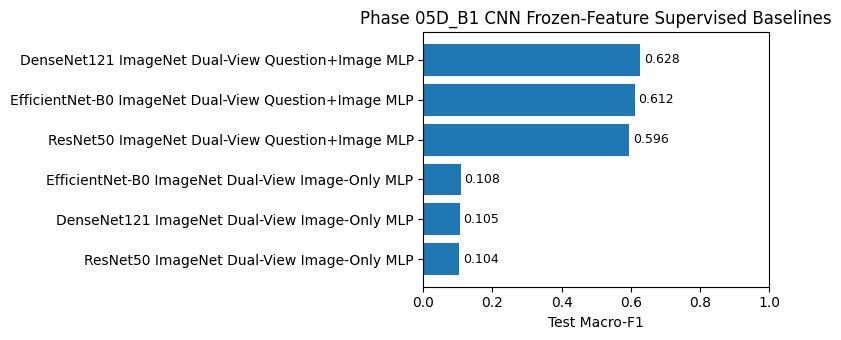

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/figures/phase05d_b1_answer_quality_comparison.png


{'finished_at': '2026-06-05 21:02:44',
 'run_mode': 'full',
 'output_dir': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines',
 'summary_table': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/tables/phase05d_b1_summary.csv',
 'comparison_table': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines/tables/phase05d_b1_vs_qadp_a4_comparison.csv',
 'input_policy_report': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_base

In [13]:
run_rows = []
for report in run_reports:
    row = {
        "tier": f"Tier 2 - supervised frozen {PHASE_KEY.upper()} visual-backbone baseline",
        "backbone_key": report.get("backbone_key", ""),
        "model_key": report["model_key"],
        "model_label": report["model_label"],
        "seed": report["seed"],
        "best_epoch": report["best_epoch"],
        "best_val_macro_f1": report["best_val_macro_f1"],
    }
    row.update({f"val_{k}": v for k, v in report["validation"].items()})
    row.update({f"test_{k}": v for k, v in report["test"].items()})
    run_rows.append(row)

run_summary_df = pd.DataFrame(run_rows).sort_values(["model_key", "seed"]).reset_index(drop=True)
save_dataframe(run_summary_df, TABLES_DIR / f"phase05d_{PHASE_KEY}_run_summary.csv")

agg_rows = []
for model_key, group in run_summary_df.groupby("model_key", sort=False):
    label = group["model_label"].iloc[0]
    row = {
        "tier": group["tier"].iloc[0],
        "backbone_key": group["backbone_key"].iloc[0],
        "model_key": model_key,
        "model_label": label,
        "num_seeds": int(group["seed"].nunique()),
    }
    for metric in ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll", "aurc", "mean_confidence"]:
        col = f"test_{metric}"
        if col in group.columns:
            row[f"{metric}_mean"] = float(group[col].mean())
            row[f"{metric}_std"] = float(group[col].std(ddof=0))
    agg_rows.append(row)

aggregate_df = pd.DataFrame(agg_rows).sort_values(["macro_f1_mean", "accuracy_mean"], ascending=False).reset_index(drop=True)
save_dataframe(aggregate_df, TABLES_DIR / f"phase05d_{PHASE_KEY}_summary.csv")

comparison_rows = []
for _, row in aggregate_df.iterrows():
    comparison_rows.append(
        {
            "tier": row["tier"],
            "model_label": row["model_label"],
            "accuracy": row.get("accuracy_mean", np.nan),
            "macro_f1": row.get("macro_f1_mean", np.nan),
            "weighted_f1": row.get("weighted_f1_mean", np.nan),
            "ece": row.get("ece_mean", np.nan),
            "brier": row.get("brier_mean", np.nan),
            "nll": row.get("nll_mean", np.nan),
            "aurc": row.get("aurc_mean", np.nan),
            "num_seeds": row["num_seeds"],
            "comparison_role": f"training-matched supervised frozen {PHASE_KEY.upper()} visual-backbone baseline",
        }
    )

phase5b_answer_table = PHASE5B_RESULT_DIR / "tables" / "phase5b_clean_metadata_four_seeds_answer_backbone_table.csv"
if phase5b_answer_table.exists():
    q_df = pd.read_csv(phase5b_answer_table)
    for _, src in q_df.iterrows():
        model_label = str(src.get("model_label", src.get("model", "")))
        comparison_rows.append(
            {
                "tier": "Tier 1 - clean supervised proposed-model ablation",
                "model_label": model_label,
                "accuracy": src.get("accuracy", src.get("test_accuracy_mean", np.nan)),
                "macro_f1": src.get("macro_f1", src.get("test_macro_f1_mean", np.nan)),
                "weighted_f1": src.get("weighted_f1", src.get("test_weighted_f1_mean", np.nan)),
                "ece": np.nan,
                "brier": np.nan,
                "nll": np.nan,
                "aurc": np.nan,
                "num_seeds": src.get("num_seeds", 4),
                "comparison_role": "clean supervised proposed-model ablation from Phase 05B",
            }
        )
else:
    print("Phase 05B answer table not found; baseline-only comparison will be saved.")

a4_summary = PHASE5D_BASE_DIR / "phase05d_a4_biomedclip_frozen_feature_supervised_baseline" / "tables" / "phase05d_a4_supervised_biomedclip_summary.csv"
if a4_summary.exists():
    a4_df = pd.read_csv(a4_summary)
    for _, src in a4_df.iterrows():
        comparison_rows.append(
            {
                "tier": "Tier 2 - supervised frozen BiomedCLIP feature baseline",
                "model_label": src.get("model_label", ""),
                "accuracy": src.get("accuracy_mean", np.nan),
                "macro_f1": src.get("macro_f1_mean", np.nan),
                "weighted_f1": src.get("weighted_f1_mean", np.nan),
                "ece": src.get("ece_mean", np.nan),
                "brier": src.get("brier_mean", np.nan),
                "nll": src.get("nll_mean", np.nan),
                "aurc": src.get("aurc_mean", np.nan),
                "num_seeds": src.get("num_seeds", np.nan),
                "comparison_role": "completed A4 supervised BiomedCLIP feature baseline",
            }
        )

comparison_df = pd.DataFrame(comparison_rows)
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values(["tier", "macro_f1", "accuracy"], ascending=[True, False, False]).reset_index(drop=True)
save_dataframe(comparison_df, TABLES_DIR / f"phase05d_{PHASE_KEY}_vs_qadp_a4_comparison.csv")

plot_df = aggregate_df.copy()
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.55 * len(plot_df))))
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["macro_f1_mean"], color="#1f77b4")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["model_label"])
    ax.invert_yaxis()
    ax.set_xlabel("Test Macro-F1")
    ax.set_title(PHASE_NAME)
    ax.set_xlim(0, 1.0)
    for idx, value in enumerate(plot_df["macro_f1_mean"].tolist()):
        ax.text(value + 0.01, idx, f"{value:.3f}", va="center", fontsize=9)
    fig.tight_layout()
    fig_path = FIGURES_DIR / f"phase05d_{PHASE_KEY}_answer_quality_comparison.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved", fig_path)

completion_report = {
    "finished_at": now_string(),
    "run_mode": RUN_MODE,
    "output_dir": str(PHASE5D_RUN_DIR),
    "summary_table": str(TABLES_DIR / f"phase05d_{PHASE_KEY}_summary.csv"),
    "comparison_table": str(TABLES_DIR / f"phase05d_{PHASE_KEY}_vs_qadp_a4_comparison.csv"),
    "input_policy_report": str(REPORTS_DIR / f"phase05d_{PHASE_KEY}_input_policy_report.json"),
    "interpretation": [
        f"{PHASE_NAME} is a training-matched supervised frozen visual-backbone baseline.",
        "The visual backbone is frozen; only MLP heads are trained.",
        "The baseline uses frozen raw and MONAI-overlay image features plus optional Phase 3B question embeddings.",
        "The baseline does not use QAdp visual_tokens, region_aux, UGTM/PRUGTM/Q-CUR outputs, audit metadata, candidate filtering, or gold fallback.",
    ],
}
write_json(DONE_DIR / f"phase05d_{PHASE_KEY}_complete.json", completion_report)
completion_report
